In [1]:
import os
print(os.getcwd())

/Users/fahime


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# Set the path
path = '/Users/fahime/Downloads/project data analyst/premier_league_analysis/archive/'

# Load the main dataset
df = pd.read_csv(path + 'final_dataset.csv')

print(df.shape)
print(df.dtypes)
df.head()

(6840, 40)
Unnamed: 0         int64
Date              object
HomeTeam          object
AwayTeam          object
FTHG               int64
FTAG               int64
FTR               object
HTGS               int64
ATGS               int64
HTGC               int64
ATGC               int64
HTP              float64
ATP              float64
HM1               object
HM2               object
HM3               object
HM4               object
HM5               object
AM1               object
AM2               object
AM3               object
AM4               object
AM5               object
MW               float64
HTFormPtsStr      object
ATFormPtsStr      object
HTFormPts          int64
ATFormPts          int64
HTWinStreak3       int64
HTWinStreak5       int64
HTLossStreak3      int64
HTLossStreak5      int64
ATWinStreak3       int64
ATWinStreak5       int64
ATLossStreak3      int64
ATLossStreak5      int64
HTGD             float64
ATGD             float64
DiffPts          float64
DiffFormPts   

,Unnamed: 0,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,0,19/08/00,Charlton,Man City,4,0,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,1,19/08/00,Chelsea,West Ham,4,2,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
2,2,19/08/00,Coventry,Middlesbrough,1,3,NH,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
3,3,19/08/00,Derby,Southampton,2,2,NH,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
4,4,19/08/00,Leeds,Everton,2,0,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0


In [4]:
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDate range:")
print(df['Date'].min(), "to", df['Date'].max())

(6840, 40)

Columns:
['Unnamed: 0', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 'HM1', 'HM2', 'HM3', 'HM4', 'HM5', 'AM1', 'AM2', 'AM3', 'AM4', 'AM5', 'MW', 'HTFormPtsStr', 'ATFormPtsStr', 'HTFormPts', 'ATFormPts', 'HTWinStreak3', 'HTWinStreak5', 'HTLossStreak3', 'HTLossStreak5', 'ATWinStreak3', 'ATWinStreak5', 'ATLossStreak3', 'ATLossStreak5', 'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts']

Missing values:
Series([], dtype: int64)

Date range:
01/01/01 to 31/12/17


In [5]:
# Fix date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Season'] = df['Date'].dt.year.apply(lambda x: f"{x}-{x+1}" if df.loc[df['Date'].dt.year == x, 'Date'].dt.month.min() >= 8 else f"{x-1}-{x}")
df['Season'] = df['Date'].apply(lambda x: f"{x.year}-{x.year+1}" if x.month >= 8 else f"{x.year-1}-{x.year}")

# Check result values
print("Result types:", df['FTR'].unique())
print("Total matches:", len(df))
print("Seasons:", sorted(df['Season'].unique()))


/var/folders/v7/lwqtq6_s3f14z2x2v7vnnblh0000gn/T/ipykernel_60345/70190080.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


Result types: ['H' 'NH']
Total matches: 6840
Seasons: ['2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018']


Home wins: 3176 (46.4%)
Away wins or draws: 3664 (53.6%)

Avg home goals per game: 1.53
Avg away goals per game: 1.13


/var/folders/v7/lwqtq6_s3f14z2x2v7vnnblh0000gn/T/ipykernel_60345/2276676650.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  season_hw = df.groupby('Season').apply(


Text(0.5, 1.0, 'Overall Match Outcomes')

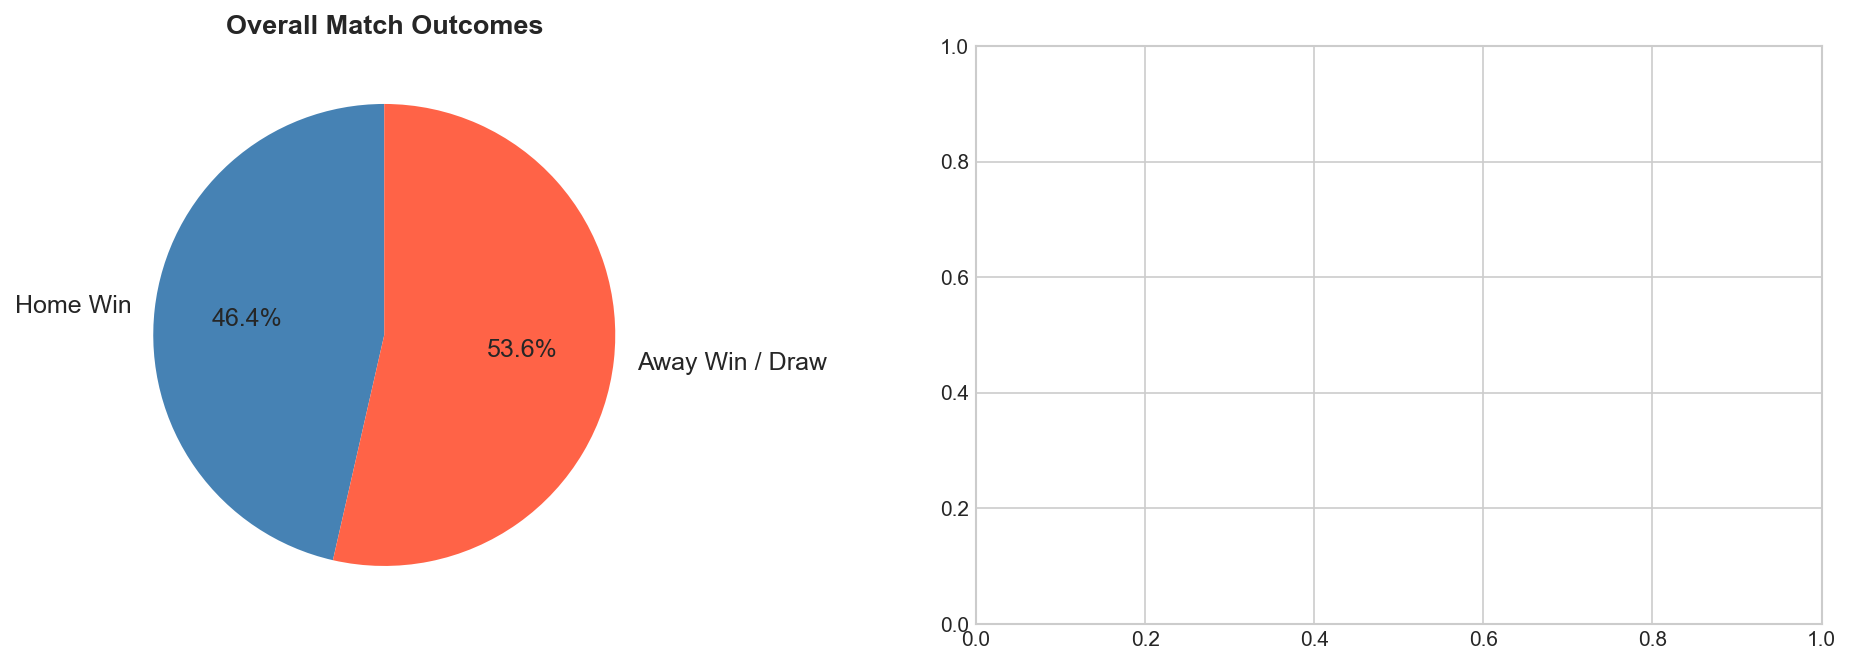

In [6]:
# Overall home vs away win rates
result_counts = df['FTR'].value_counts()
home_wins = result_counts['H']
not_home = result_counts['NH']
total = len(df)

print(f"Home wins: {home_wins} ({home_wins/total*100:.1f}%)")
print(f"Away wins or draws: {not_home} ({not_home/total*100:.1f}%)")

# Goals per game
avg_home_goals = df['FTHG'].mean()
avg_away_goals = df['FTAG'].mean()
print(f"\nAvg home goals per game: {avg_home_goals:.2f}")
print(f"Avg away goals per game: {avg_away_goals:.2f}")

# Home win rate per season
season_hw = df.groupby('Season').apply(
    lambda x: (x['FTR'] == 'H').sum() / len(x) * 100
).reset_index()
season_hw.columns = ['Season', 'HomeWinRate']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: pie chart
axes[0].pie([home_wins, not_home], 
            labels=['Home Win', 'Away Win / Draw'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Overall Match Outcomes', fontsize=13, fontweight='bold')

# Right: home win rate per sea

/var/folders/v7/lwqtq6_s3f14z2x2v7vnnblh0000gn/T/ipykernel_60345/792667445.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  season_hw = df.groupby('Season').apply(


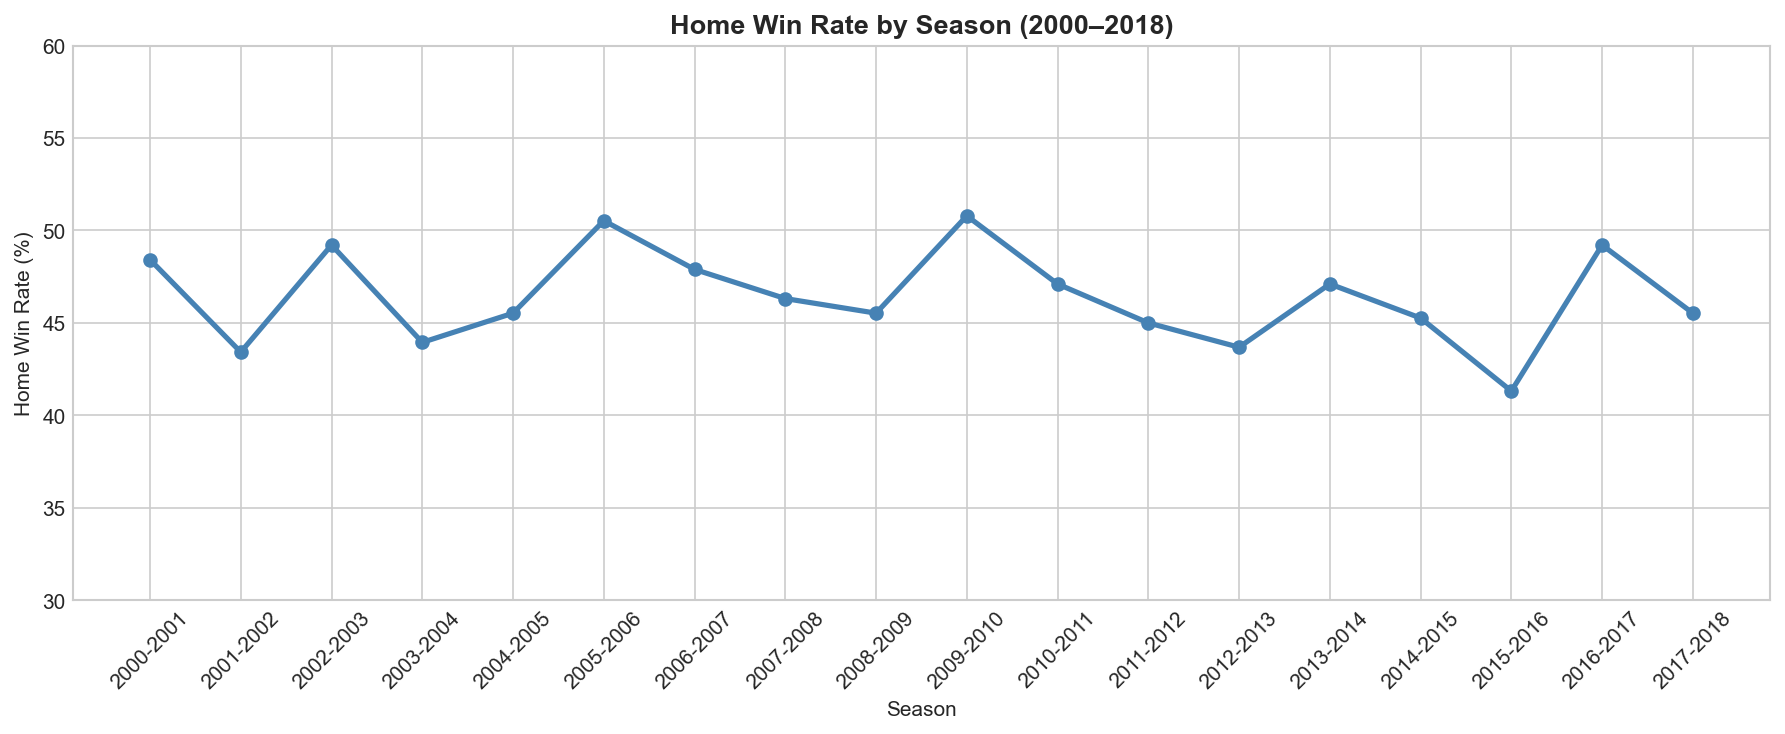

       Season  HomeWinRate
0   2000-2001    48.421053
1   2001-2002    43.421053
2   2002-2003    49.210526
3   2003-2004    43.947368
4   2004-2005    45.526316
5   2005-2006    50.526316
6   2006-2007    47.894737
7   2007-2008    46.315789
8   2008-2009    45.526316
9   2009-2010    50.789474
10  2010-2011    47.105263
11  2011-2012    45.000000
12  2012-2013    43.684211
13  2013-2014    47.105263
14  2014-2015    45.263158
15  2015-2016    41.315789
16  2016-2017    49.210526
17  2017-2018    45.526316


In [8]:
# Fixed version - compatible with all pandas versions
season_hw = df.groupby('Season').apply(
    lambda x: (x['FTR'] == 'H').sum() / len(x) * 100
).reset_index()
season_hw.columns = ['Season', 'HomeWinRate']

# Plot just the season trend
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(season_hw['Season'], season_hw['HomeWinRate'], 
        marker='o', color='steelblue', linewidth=2.5)
ax.set_xlabel('Season')
ax.set_ylabel('Home Win Rate (%)')
ax.set_title('Home Win Rate by Season (2000–2018)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(30, 60)

plt.tight_layout()
plt.savefig('home_advantage_trend.png', dpi=150)
plt.show()

print(season_hw)

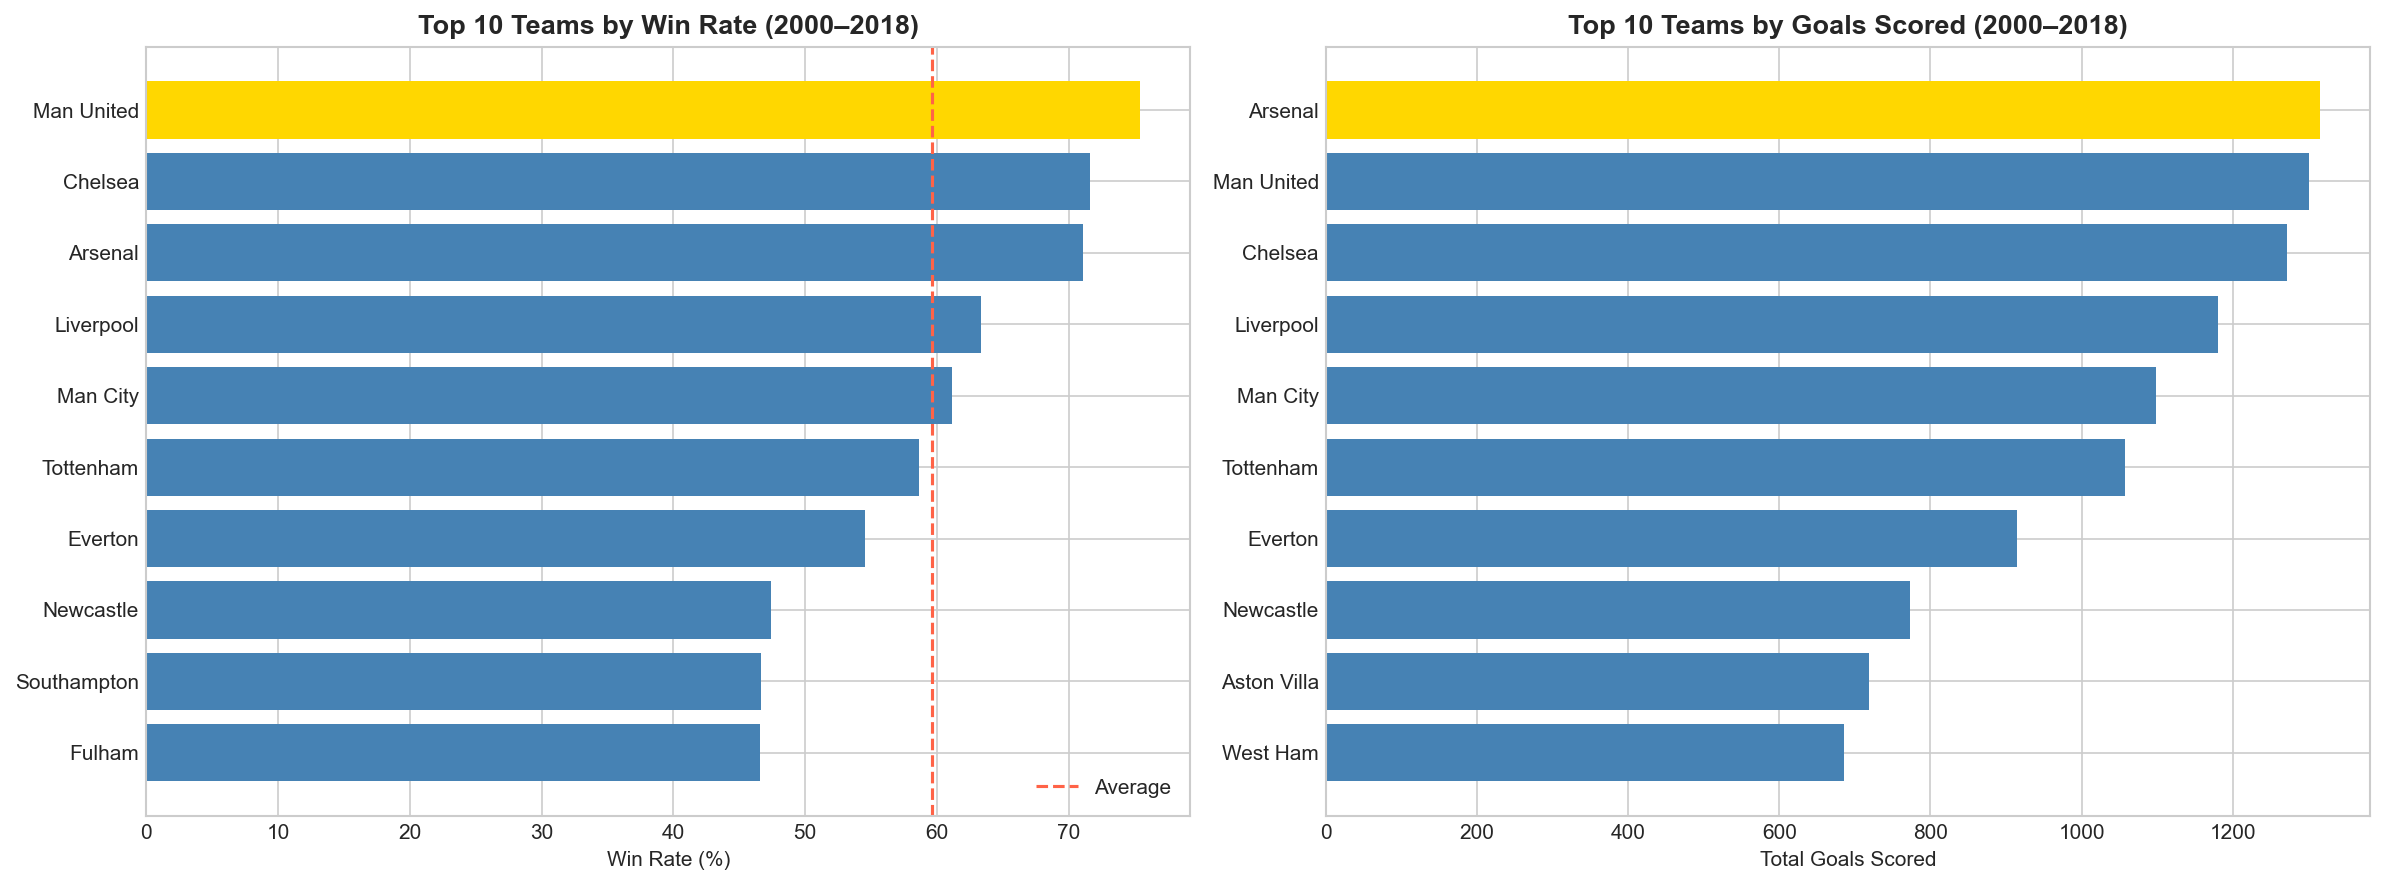

Top 10 Win Rates:
HomeTeam
Man United     75.4
Chelsea        71.6
Arsenal        71.1
Liverpool      63.3
Man City       61.1
Tottenham      58.6
Everton        54.5
Newcastle      47.4
Southampton    46.7
Fulham         46.6
dtype: float64


In [9]:
# Calculate win rate per team across all seasons
home_wins_by_team = df[df['FTR'] == 'H'].groupby('HomeTeam').size()
home_games_by_team = df.groupby('HomeTeam').size()

away_wins_by_team = df[df['FTR'] == 'NH'].groupby('AwayTeam').size()
away_games_by_team = df.groupby('AwayTeam').size()

# Total wins and games
total_wins = home_wins_by_team.add(away_wins_by_team, fill_value=0)
total_games = home_games_by_team.add(away_games_by_team, fill_value=0)
win_rate = (total_wins / total_games * 100).sort_values(ascending=False)

# Keep only teams with 200+ games (consistent PL teams)
win_rate = win_rate[total_games >= 200].head(10)

# Total goals scored
home_goals = df.groupby('HomeTeam')['FTHG'].sum()
away_goals = df.groupby('AwayTeam')['FTAG'].sum()
total_goals = home_goals.add(away_goals, fill_value=0)
top_scorers = total_goals[total_games >= 200].sort_values(ascending=False).head(10)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: win rate
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(win_rate))]
axes[0].barh(win_rate.index[::-1], win_rate.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Win Rate (%)')
axes[0].set_title('Top 10 Teams by Win Rate (2000–2018)', fontsize=13, fontweight='bold')
axes[0].axvline(win_rate.values.mean(), color='tomato', linestyle='--', label='Average')
axes[0].legend()

# Right: total goals
colors2 = ['gold' if i == 0 else 'steelblue' for i in range(len(top_scorers))]
axes[1].barh(top_scorers.index[::-1], top_scorers.values[::-1], color=colors2[::-1])
axes[1].set_xlabel('Total Goals Scored')
axes[1].set_title('Top 10 Teams by Goals Scored (2000–2018)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('top_teams.png', dpi=150)
plt.show()

print("Top 10 Win Rates:")
print(win_rate.round(1))


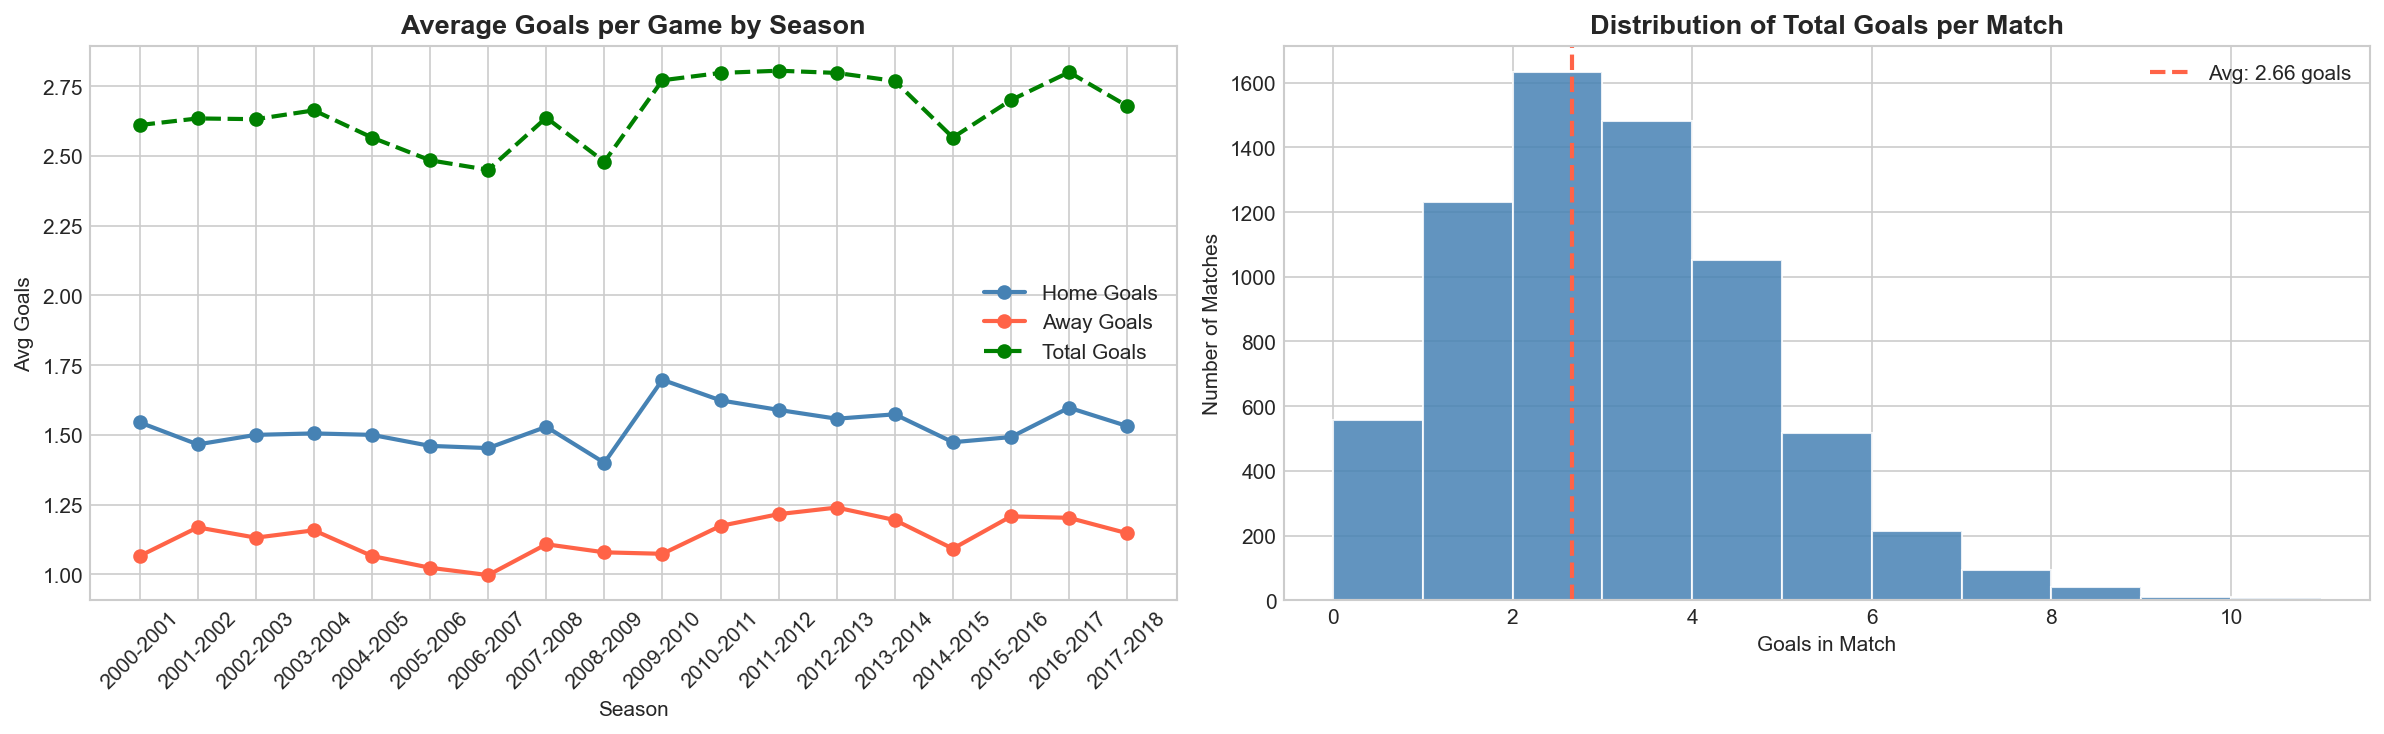

Most common scoreline total: 2 goals
% of games with 2 or fewer goals: 50.0%
% of games with 4+ goals: 28.3%


In [11]:
# Goals per game trend by season
season_goals = df.groupby('Season').agg(
    avg_home_goals=('FTHG', 'mean'),
    avg_away_goals=('FTAG', 'mean')
).reset_index()
season_goals['avg_total'] = season_goals['avg_home_goals'] + season_goals['avg_away_goals']

df['TotalGoals'] = df['FTHG'] + df['FTAG']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: goals per game by season
axes[0].plot(season_goals['Season'], season_goals['avg_home_goals'],
             marker='o', label='Home Goals', color='steelblue', linewidth=2)
axes[0].plot(season_goals['Season'], season_goals['avg_away_goals'],
             marker='o', label='Away Goals', color='tomato', linewidth=2)
axes[0].plot(season_goals['Season'], season_goals['avg_total'],
             marker='o', label='Total Goals', color='green', linewidth=2, linestyle='--')
axes[0].set_title('Average Goals per Game by Season', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Avg Goals')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Right: distribution of total goals per match
axes[1].hist(df['TotalGoals'], bins=range(0, 12), color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(df['TotalGoals'].mean(), color='tomato', linestyle='--',
                linewidth=2, label=f"Avg: {df['TotalGoals'].mean():.2f} goals")
axes[1].set_title('Distribution of Total Goals per Match', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Goals in Match')
axes[1].set_ylabel('Number of Matches')
axes[1].legend()

plt.tight_layout()
plt.savefig('goals_analysis.png', dpi=150)
plt.show()

print(f"Most common scoreline total: {df['TotalGoals'].mode()[0]} goals")
print(f"% of games with 2 or fewer goals: {(df['TotalGoals'] <= 2).mean()*100:.1f}%")
print(f"% of games with 4+ goals: {(df['TotalGoals'] >= 4).mean()*100:.1f}%")

/var/folders/v7/lwqtq6_s3f14z2x2v7vnnblh0000gn/T/ipykernel_60345/1535808071.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ht_form_win = df.groupby('HTForm_cat', observed=True).apply(
/var/folders/v7/lwqtq6_s3f14z2x2v7vnnblh0000gn/T/ipykernel_60345/1535808071.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  at_form_win = df.groupby('ATForm_cat', observed=True).apply(


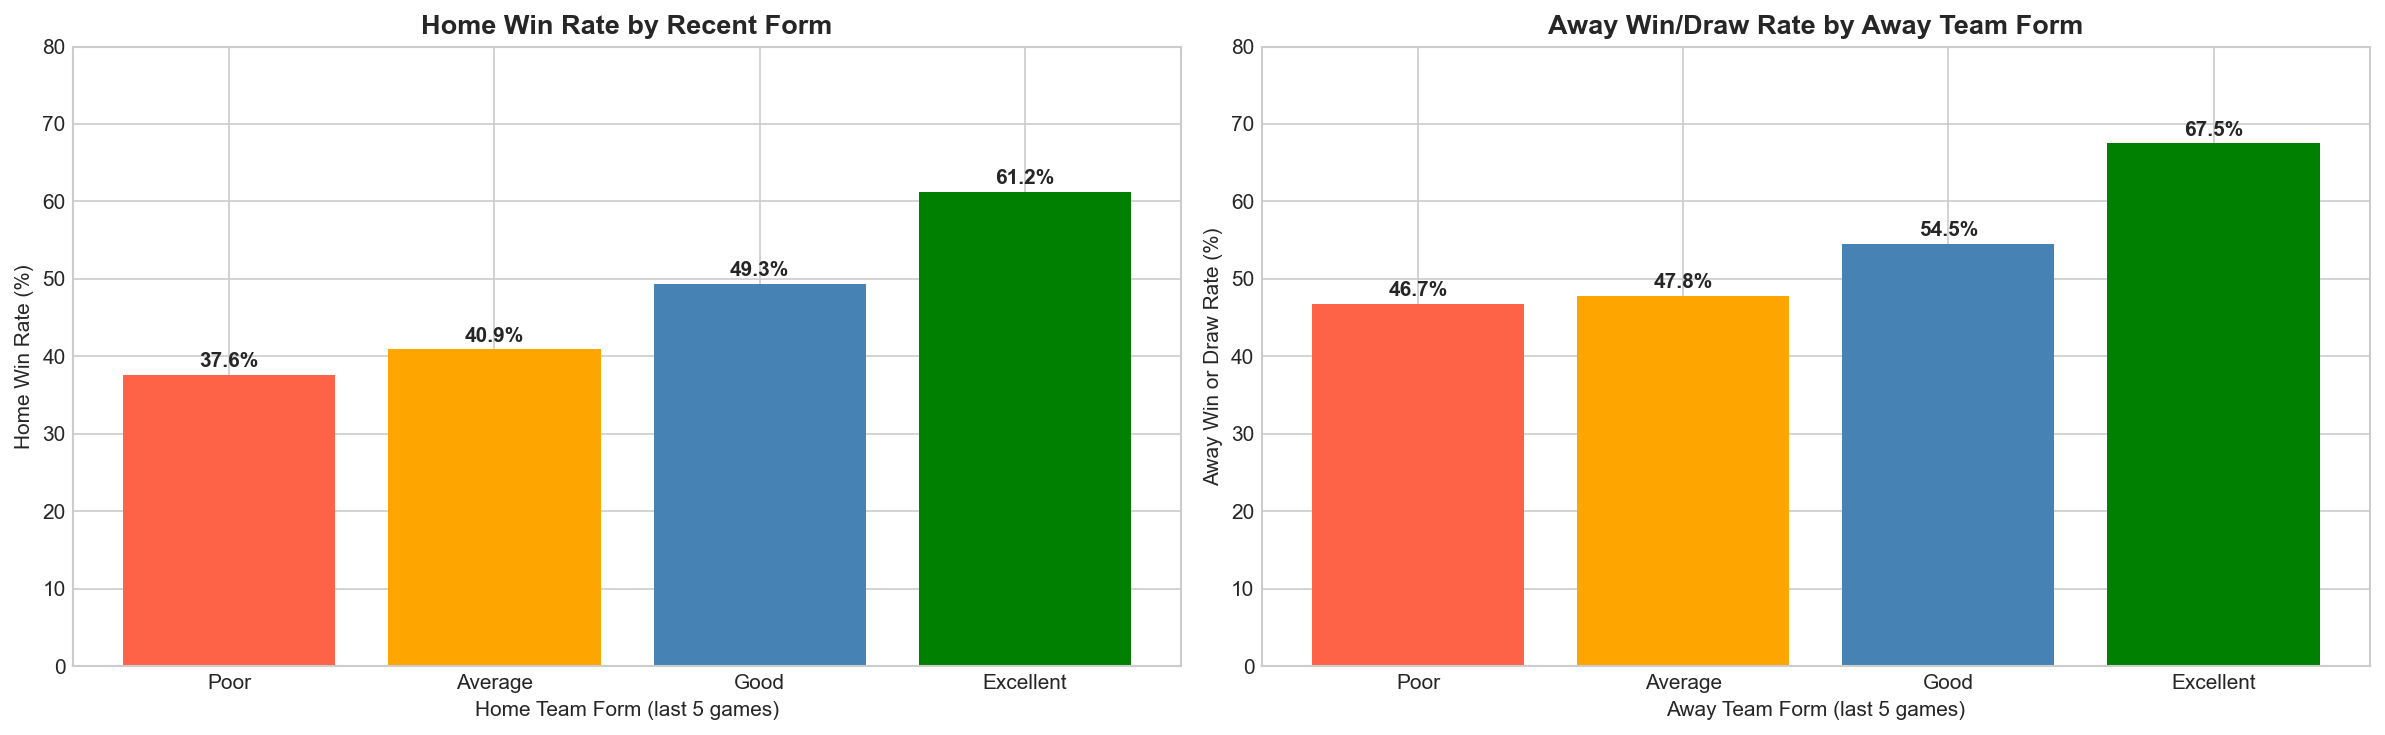

Correlation: Points difference vs Home Win: 0.302
Correlation: Form points difference vs Home Win: 0.197


In [12]:
# Does home team form predict winning?
# HTFormPts = home team's recent form points, HTP = cumulative points

# Bin form points into categories
df['HTForm_cat'] = pd.cut(df['HTFormPts'], bins=[-1, 3, 6, 9, 15],
                           labels=['Poor', 'Average', 'Good', 'Excellent'])
df['ATForm_cat'] = pd.cut(df['ATFormPts'], bins=[-1, 3, 6, 9, 15],
                           labels=['Poor', 'Average', 'Good', 'Excellent'])

# Win rate by home team form
ht_form_win = df.groupby('HTForm_cat', observed=True).apply(
    lambda x: (x['FTR'] == 'H').sum() / len(x) * 100
).reset_index()
ht_form_win.columns = ['Form', 'HomeWinRate']

# Win rate by away team form  
at_form_win = df.groupby('ATForm_cat', observed=True).apply(
    lambda x: (x['FTR'] == 'NH').sum() / len(x) * 100
).reset_index()
at_form_win.columns = ['Form', 'AwayWinOrDrawRate']

# Correlation between point difference and result
df['HomeWin'] = (df['FTR'] == 'H').astype(int)
corr_pts = df['DiffPts'].corr(df['HomeWin'])
corr_form = df['DiffFormPts'].corr(df['HomeWin'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: home win rate by form
colors = ['tomato', 'orange', 'steelblue', 'green']
axes[0].bar(ht_form_win['Form'], ht_form_win['HomeWinRate'], color=colors)
axes[0].set_title('Home Win Rate by Recent Form', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Home Team Form (last 5 games)')
axes[0].set_ylabel('Home Win Rate (%)')
axes[0].set_ylim(0, 80)
for i, v in enumerate(ht_form_win['HomeWinRate']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Right: away form effect
axes[1].bar(at_form_win['Form'], at_form_win['AwayWinOrDrawRate'], color=colors)
axes[1].set_title('Away Win/Draw Rate by Away Team Form', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Away Team Form (last 5 games)')
axes[1].set_ylabel('Away Win or Draw Rate (%)')
axes[1].set_ylim(0, 80)
for i, v in enumerate(at_form_win['AwayWinOrDrawRate']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('form_analysis.png', dpi=150)
plt.show()

print(f"Correlation: Points difference vs Home Win: {corr_pts:.3f}")
print(f"Correlation: Form points difference vs Home Win: {corr_form:.3f}")

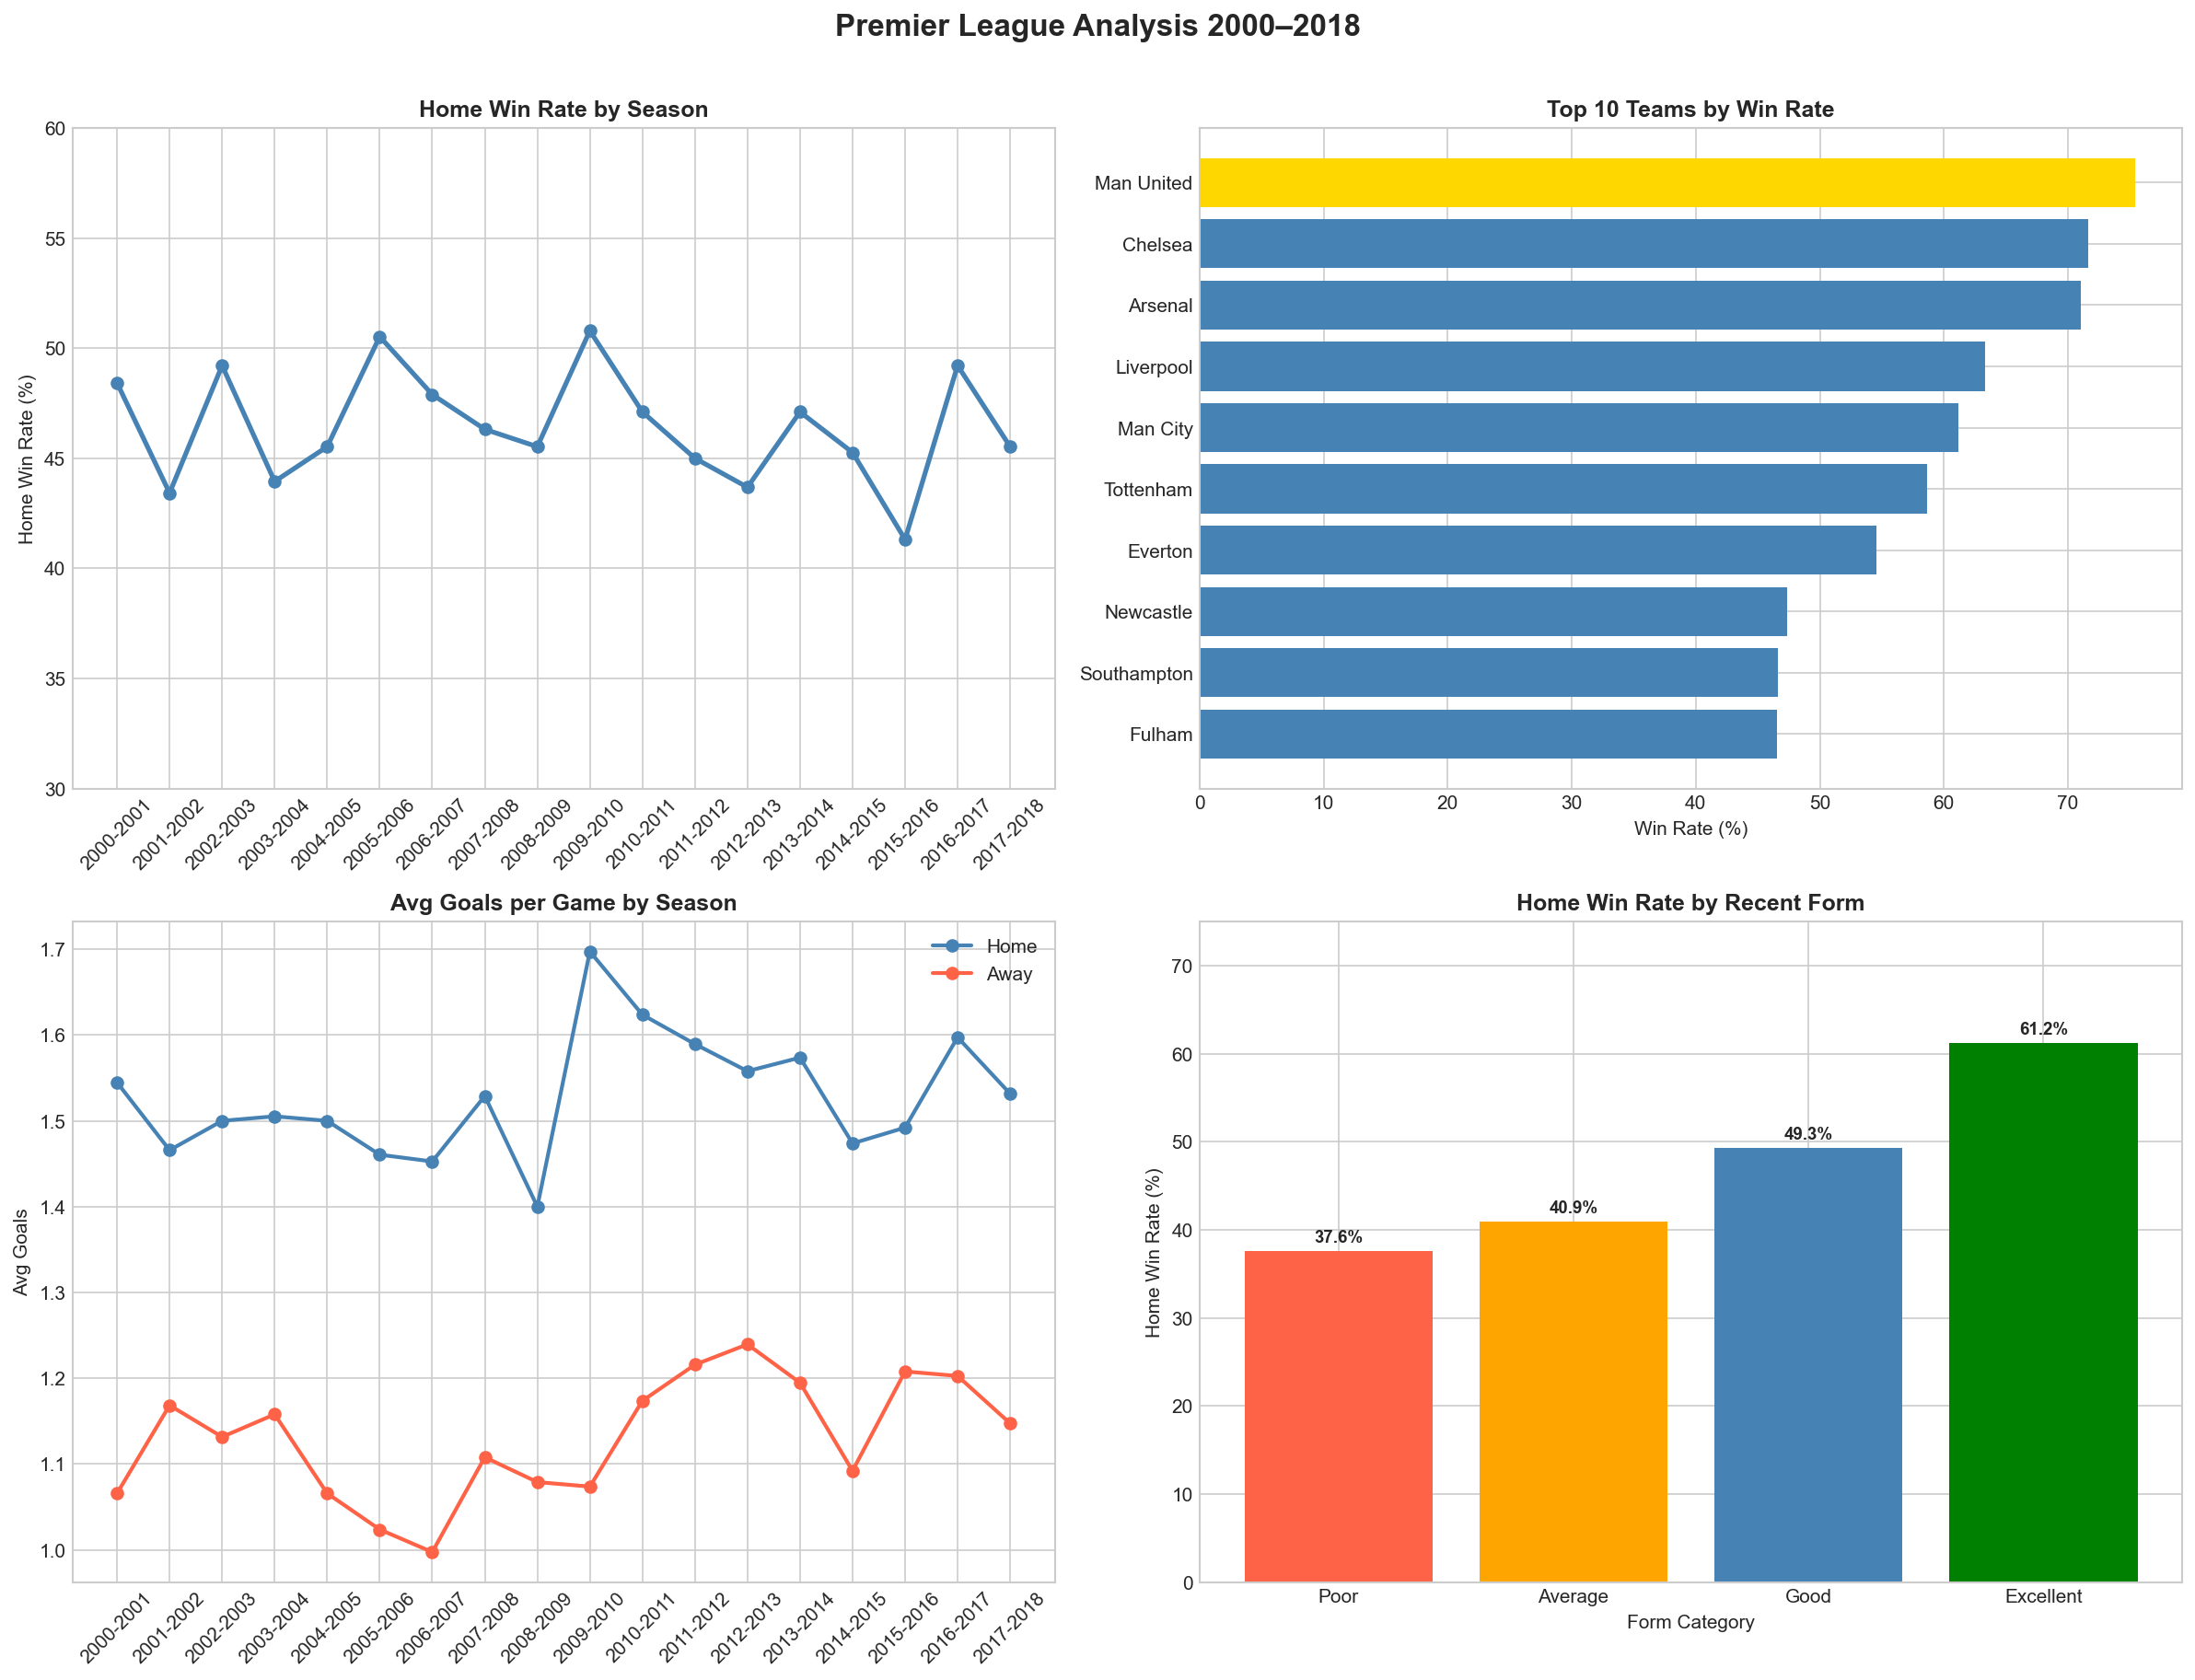

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Premier League Analysis 2000–2018', fontsize=16, fontweight='bold', y=1.01)

# Top left: home win rate by season
axes[0,0].plot(season_hw['Season'], season_hw['HomeWinRate'],
               marker='o', color='steelblue', linewidth=2.5)
axes[0,0].set_title('Home Win Rate by Season', fontweight='bold')
axes[0,0].set_ylabel('Home Win Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylim(30, 60)

# Top right: top 10 teams by win rate
axes[0,1].barh(win_rate.index[::-1], win_rate.values[::-1],
               color=['gold' if i == len(win_rate)-1 else 'steelblue' for i in range(len(win_rate))])
axes[0,1].set_title('Top 10 Teams by Win Rate', fontweight='bold')
axes[0,1].set_xlabel('Win Rate (%)')

# Bottom left: goals per season
axes[1,0].plot(season_goals['Season'], season_goals['avg_home_goals'],
               marker='o', label='Home', color='steelblue', linewidth=2)
axes[1,0].plot(season_goals['Season'], season_goals['avg_away_goals'],
               marker='o', label='Away', color='tomato', linewidth=2)
axes[1,0].set_title('Avg Goals per Game by Season', fontweight='bold')
axes[1,0].set_ylabel('Avg Goals')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# Bottom right: form vs win rate
axes[1,1].bar(ht_form_win['Form'], ht_form_win['HomeWinRate'],
              color=['tomato', 'orange', 'steelblue', 'green'])
axes[1,1].set_title('Home Win Rate by Recent Form', fontweight='bold')
axes[1,1].set_ylabel('Home Win Rate (%)')
axes[1,1].set_xlabel('Form Category')
axes[1,1].set_ylim(0, 75)
for i, v in enumerate(ht_form_win['HomeWinRate']):
    axes[1,1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('premier_league_summary.png', dpi=150, bbox_inches='tight')
plt.show()
